In [10]:
from langgraph.graph import StateGraph,START,END
from typing import Annotated,TypedDict
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import HumanMessage,AIMessage,BaseMessage
from pydantic import BaseModel
import os

In [11]:
load_dotenv()

MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

if MISTRAL_API_KEY is None:
    raise ValueError("MISTRAL_API_KEY is not avaiable in env.")

In [12]:
llm = ChatMistralAI(
    model_name = 'open-mistral-nemo',
    temperature=0.7,
    max_tokens= 1024,
    api_key=os.environ["MISTRAL_API_KEY"]
)

response = llm.invoke([HumanMessage(content="what is you name?\n")])
print(response.content)

I don't have a name. I'm a text-based AI model and I don't have personal experiences, feelings, or a consciousness. You can call me "Assistant" or give me a name if you'd like, but it won't change my functionality. How can I assist you today?


In [7]:
# we have to make a Simple Chatbot 

In [34]:
from langgraph.graph.message import add_messages

class SimpleChatbot(TypedDict):
    message: Annotated[list[BaseMessage],add_messages]

In [35]:
def chatbotMessage(state: SimpleChatbot):
    # take query from the user
    message = state['message']

    # send it to llm
    response = llm.invoke(message)

    return {'message':response}


In [36]:
# lets define a graph
graph = StateGraph(SimpleChatbot)

# add node of graph
graph.add_node("chatbotMessage",chatbotMessage)

# add edges to graph
graph.add_edge(START,'chatbotMessage')
graph.add_edge('chatbotMessage',END)

workflow = graph.compile()

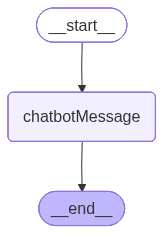

In [37]:
workflow

In [39]:
initial_state = {
    'message':[HumanMessage(content="what is the capital of india?\n")]
}

workflow.invoke(initial_state)['message'][-1].content

"The capital of India is New Delhi. It's the largest commercial city in northern India and an important international gateway to the country. Here are a few key points about New Delhi:\n\n1. **History**: New Delhi was established in 1911 by the British as the new capital of the British Raj, replacing Calcutta (now Kolkata). It was officially inaugurated in 1931.\n\n2. **Population**: As of 2021, the population of New Delhi is estimated to be over 30 million.\n\n3. **Landmarks**: Some of the notable landmarks in New Delhi include the India Gate, Red Fort, Rashtrapati Bhavan (the official residence of the President of India), and the Lotus Temple.\n\n4. **Culture and Cuisine**: New Delhi is known for its rich cultural heritage, historical monuments, and diverse cuisine. It's also a major commercial and political hub.\n\n5. **Language**: Hindi is the official language, but English is also widely spoken."

In [41]:
while True:
    user_message = input('Type here: ')
    print(f'User_message: {user_message}\n')

    # FIX 1: Check if message is in exit list (use `in` not `is`)
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    # FIX 2: Make sure workflow is the compiled app, and state structure matches
    response = workflow.invoke({'message': [HumanMessage(content=user_message)]})  # Changed to 'messages'

    # FIX 3: Access the content safely
    print(f'AIMessage: {response["message"][-1].content}')  # Changed to 'messages'

User_message: do you know PM modi

AIMessage: Yes, I do. PM stands for Prime Minister, and Narendra Modi is the current Prime Minister of India. Here are a few key points about him:

1. **Full Name**: Narendra Damodardas Modi
2. **Date of Birth**: 17 September 1950
3. **Political Party**: Bharatiya Janata Party (BJP)
4. **Term as Prime Minister**: He has been the Prime Minister of India since 26 May 2014. He was re-elected in 2019 and is currently serving his second term.
5. **Previous Roles**: Before becoming the Prime Minister, he served as the Chief Minister of Gujarat from 2001 to 2014.
6. **Notable Initiatives**: Some of the key initiatives and campaigns associated with him include Swachh Bharat Abhiyan (Clean India Mission), Make in India, Digital India, and Ayushman Bharat (a national health protection scheme).
7. **Personal Life**: Modi is a vegetarian and a teetotaler. He is known for his frugal lifestyle and is often seen wearing a simple, hand-woven cotton cloth called a 'kh